# Lab 1: Projectile Motion Solver

Name: Aidan Siddiqi
Date: 8/29/2026
Lab: PHYS 311 Module 1

This notebook implements the Euler method to simulate 1D free fall, 2D projectile motion without drag, and 2D projectile motion with quadratic air resistance.

**AI use disclaimer:** AI (Claude) was used in preparing this notebook for coding assistance, tidying up code, and improving code flow/organization. This is not to say that there was no human work done in this code; all lines included input and assistance from myself and many iterations and human attempts are consolidated into the notebook seen below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: One-Dimensional Free Fall

We drop a ball from rest at height h = 100 m under uniform gravity with no air resistance and integrate the equations of motion using the Euler method.

In [2]:
def simulate_freefall(h, dt, g=9.81):
    t, y, vy = 0.0, h, 0.0
    t_list, y_list, vy_list = [t], [y], [vy]

    while y >= 0:
        vy = vy - g * dt
        y = y + vy * dt
        t = t + dt
        t_list.append(t)
        y_list.append(y)
        vy_list.append(vy)

    return np.array(t_list), np.array(y_list), np.array(vy_list)

Run the simulation with dt = 0.1 s and h = 100 m, and compare against the exact analytic solution.

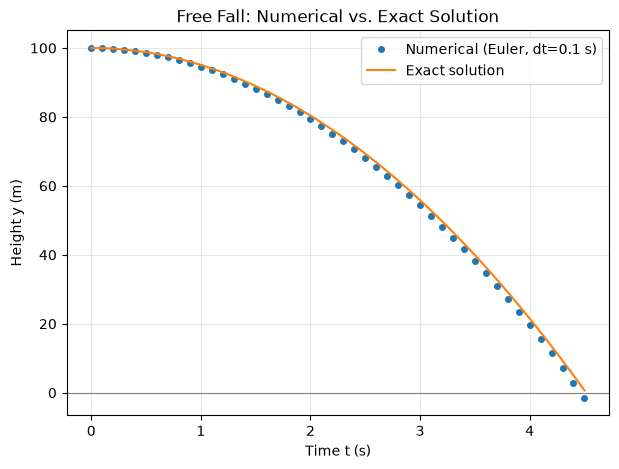

In [3]:
h = 100.0
dt = 0.1
g = 9.81

t_num, y_num, vy_num = simulate_freefall(h, dt, g)

t_exact = np.linspace(0, t_num[-1], 300)
y_exact = h - 0.5 * g * t_exact**2
vy_exact = -g * t_exact

plt.figure(figsize=(7, 5))
plt.plot(t_num, y_num, 'o', markersize=4, label='Numerical (Euler, dt=0.1 s)')
plt.plot(t_exact, y_exact, '-', label='Exact solution')
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('Time t (s)')
plt.ylabel('Height y (m)')
plt.title('Free Fall: Numerical vs. Exact Solution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
t_final_num = t_num[-1]
vy_final_num = vy_num[-1]

t_final_exact = np.sqrt(2 * h / g)
vy_final_exact = -g * t_final_exact

pct_error_t = abs(t_final_num - t_final_exact) / t_final_exact * 100

print(f"Numerical landing time: {t_final_num:.4f} s")
print(f"Exact landing time: {t_final_exact:.4f} s")
print(f"Percentage error (time): {pct_error_t:.3f} %")
print()
print(f"Numerical final velocity: {vy_final_num:.4f} m/s")
print(f"Exact final velocity: {vy_final_exact:.4f} m/s")

Numerical landing time: 4.5000 s
Exact landing time: 4.5152 s
Percentage error (time): 0.337 %

Numerical final velocity: -44.1450 m/s
Exact final velocity: -44.2945 m/s


**Q1: Numerical vs. exact landing time, and percentage error.**

The printed output above shows the numerical landing time and the percentage error between them. The Euler method slightly overshoots because it uses the velocity from the start of each step to update position, which introduces a small, systematic lag relative to the true trajectory.

In [5]:
for dt_test in [1.0, 0.1, 0.01]:
    t_t, y_t, vy_t = simulate_freefall(h, dt_test, g)
    err = abs(t_t[-1] - t_final_exact) / t_final_exact * 100
    print(f"dt = {dt_test}: landing time = {t_t[-1]:.4f} s, error = {err:.3f} %")

dt = 1.0: landing time = 5.0000 s, error = 10.736 %
dt = 0.1: landing time = 4.5000 s, error = 0.337 %
dt = 0.01: landing time = 4.5200 s, error = 0.106 %


**Q2: How does the error change with step size?**

As dt decreases from 1.0 to 0.1 to 0.01 s, the percent error in the landing time shrinks proportional to dt. Smaller steps track the true curve more closely but at the cost of more computation.

## Part B: Two-Dimensional Projectile (No Drag)

A projectile is launched from the ground at speed v_0 = 30 m/s and angle theta = 45, with gravity as the only force.

In [6]:
def simulate_projectile_2d(v0, theta_deg, dt, g=9.81):
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    t = 0.0

    t_list, x_list, y_list = [t], [x], [y]
    vx_list, vy_list = [vx], [vy]

    while y >= 0:
        vy = vy - g * dt
        x = x + vx * dt
        y = y + vy * dt
        t = t + dt

        t_list.append(t)
        x_list.append(x)
        y_list.append(y)
        vx_list.append(vx)
        vy_list.append(vy)

    return (np.array(t_list), np.array(x_list), np.array(y_list),
            np.array(vx_list), np.array(vy_list))

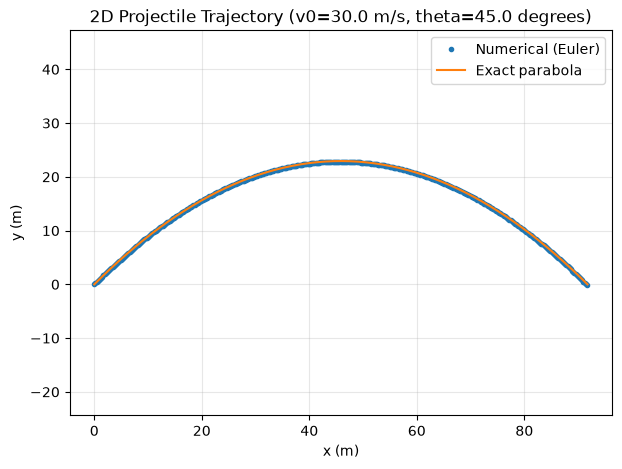

In [7]:
v0 = 30.0
theta_deg = 45.0
dt = 0.01

t_b, x_b, y_b, vx_b, vy_b = simulate_projectile_2d(v0, theta_deg, dt, g)

theta = np.radians(theta_deg)
range_exact = v0**2 * np.sin(2 * theta) / g
hmax_exact = v0**2 * np.sin(theta)**2 / (2 * g)
tflight_exact = 2 * v0 * np.sin(theta) / g

t_fine = np.linspace(0, tflight_exact, 300)
x_fine = v0 * np.cos(theta) * t_fine
y_fine = v0 * np.sin(theta) * t_fine - 0.5 * g * t_fine**2

plt.figure(figsize=(7, 5))
plt.plot(x_b, y_b, 'o', markersize=3, label='Numerical (Euler)')
plt.plot(x_fine, y_fine, '-', label='Exact parabola')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'2D Projectile Trajectory (v0={v0} m/s, theta={theta_deg} degrees)')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

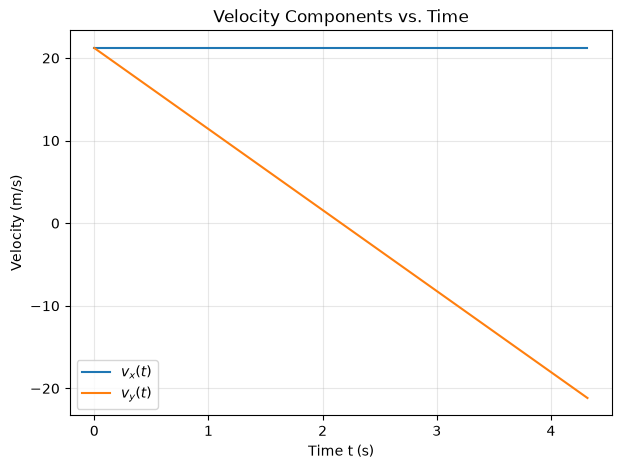

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(t_b, vx_b, label='$v_x(t)$')
plt.plot(t_b, vy_b, label='$v_y(t)$')
plt.xlabel('Time t (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity Components vs. Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Explaining the velocity curves:** v_x is a flat horizontal line because there is no horizontal force, so horizontal velocity never changes. v_y decreases linearly because the only force is the constant downward gravity, giving a constant acceleration a_y=-g. A constant acceleration produces a straight-line velocity curve.

In [9]:
range_num = x_b[-1]
hmax_num = np.max(y_b)
tflight_num = t_b[-1]

def pct_err(num, exact):
    return abs(num - exact) / exact * 100

print(f"Range: numerical = {range_num:.3f} m,  exact = {range_exact:.3f} m,  error = {pct_err(range_num, range_exact):.3f} %")
print(f"Max height: numerical = {hmax_num:.3f} m,  exact = {hmax_exact:.3f} m,  error = {pct_err(hmax_num, hmax_exact):.3f} %")
print(f"Flight time: numerical = {tflight_num:.3f} s,  exact = {tflight_exact:.3f} s,  error = {pct_err(tflight_num, tflight_exact):.3f} %")

Range: numerical = 91.641 m,  exact = 91.743 m,  error = 0.111 %
Max height: numerical = 22.830 m,  exact = 22.936 m,  error = 0.462 %
Flight time: numerical = 4.320 s,  exact = 4.325 s,  error = 0.111 %


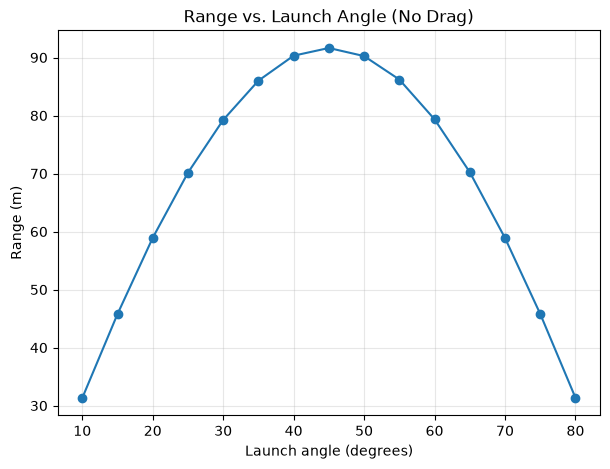

Angle that maximizes range (no drag): 45


In [10]:
angles = np.arange(10, 81, 5)
ranges_nodrag = []

for ang in angles:
    _, x_a, y_a, _, _ = simulate_projectile_2d(v0, ang, dt, g)
    ranges_nodrag.append(x_a[-1])

ranges_nodrag = np.array(ranges_nodrag)
best_angle_nodrag = angles[np.argmax(ranges_nodrag)]

plt.figure(figsize=(7, 5))
plt.plot(angles, ranges_nodrag, 'o-')
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs. Launch Angle (No Drag)')
plt.grid(alpha=0.3)
plt.show()

print(f"Angle that maximizes range (no drag): {best_angle_nodrag}")

**Q1: Why is v_x constant and v_y linear?**
Newton's second law gives a_x = F_x/m = 0 and a_y = F_y/m = -g since gravity is the only force and it acts only vertically. Zero acceleration means constant velocity (v_x = const), while constant acceleration means velocity changes linearly with time.

**Q2: Does the angle of maximum range agree with theory?**
The simulation finds the maximum range at 45 degrees, matching the theoretical result. This should hold because our simulation makes the same assumptions as the theory, meaning no drag, flat level ground, and constant gravity.

**Q3: What happens with dt = 0.5?**

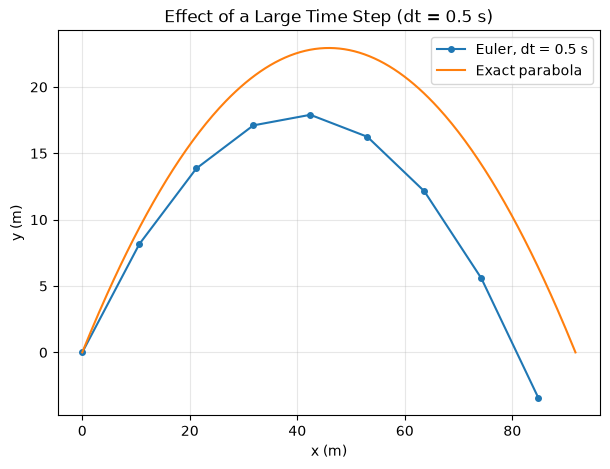

Range with dt=0.5: 84.85 m (exact range: 91.74 m)


In [11]:
t_big, x_big, y_big, vx_big, vy_big = simulate_projectile_2d(v0, theta_deg, 0.5, g)

plt.figure(figsize=(7, 5))
plt.plot(x_big, y_big, 'o-', markersize=4, label='Euler, dt = 0.5 s')
plt.plot(x_fine, y_fine, '-', label='Exact parabola')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Effect of a Large Time Step (dt = 0.5 s)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Range with dt=0.5: {x_big[-1]:.2f} m (exact range: {range_exact:.2f} m)")

With dt = 0.5 s the trajectory becomes coarse and blocky, and the computed range, max height, and flight time all diverge from the other  parabola. Because the Euler method only samples the acceleration once per step and assumes it stays constant during the whole step, big steps accumulate large errors.

## Part C: Projectile with Quadratic Air Resistance

We will now add a drag force, which opposes the velocity and grows with the square of the speed.

In [12]:
def simulate_projectile_drag(v0, theta_deg, dt, g, b_over_m):
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    t = 0.0

    t_list, x_list, y_list = [t], [x], [y]
    vx_list, vy_list = [vx], [vy]

    while y >= 0:
        speed = np.sqrt(vx**2 + vy**2)  
        ax = -b_over_m * speed * vx
        ay = -g - b_over_m * speed * vy

        vx = vx + ax * dt
        vy = vy + ay * dt
        x = x + vx * dt
        y = y + vy * dt
        t = t + dt

        t_list.append(t)
        x_list.append(x)
        y_list.append(y)
        vx_list.append(vx)
        vy_list.append(vy)

    return (np.array(t_list), np.array(x_list), np.array(y_list),
            np.array(vx_list), np.array(vy_list))

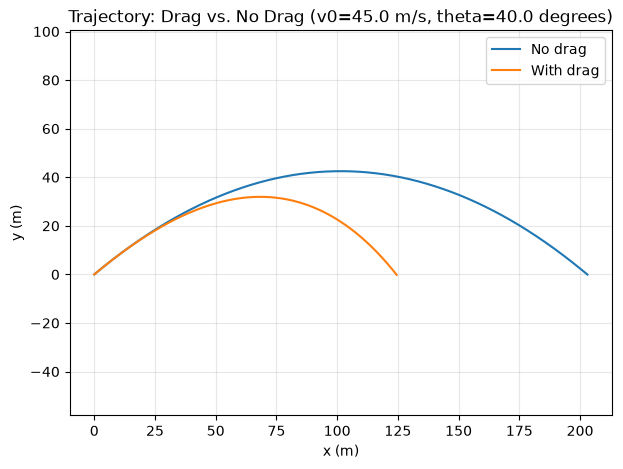

In [13]:
v0_ball = 45.0
theta_ball = 40.0
b_over_m = 0.0046
dt_c = 0.01

t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(v0_ball, theta_ball, dt_c, g, b_over_m)
t_nod, x_nod, y_nod, vx_nod, vy_nod = simulate_projectile_2d(v0_ball, theta_ball, dt_c, g)

plt.figure(figsize=(7, 5))
plt.plot(x_nod, y_nod, label='No drag')
plt.plot(x_drag, y_drag, label='With drag')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'Trajectory: Drag vs. No Drag (v0={v0_ball} m/s, theta={theta_ball} degrees)')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

In [14]:
range_nod = x_nod[-1]
hmax_nod = np.max(y_nod)
range_drag = x_drag[-1]
hmax_drag = np.max(y_drag)

pct_reduction_range = (range_nod - range_drag) / range_nod * 100

print(f"No drag range: {range_nod:.2f} m, max height: {hmax_nod:.2f} m")
print(f"With drag range: {range_drag:.2f} m, max height: {hmax_drag:.2f} m")
print(f"Drag reduces the range by {pct_reduction_range:.1f} %")

No drag range: 203.04 m, max height: 42.50 m
With drag range: 124.48 m, max height: 31.94 m
Drag reduces the range by 38.7 %


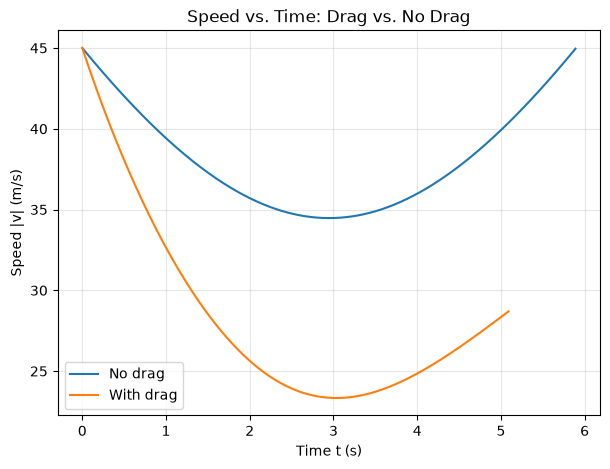

In [15]:
speed_nod = np.sqrt(vx_nod**2 + vy_nod**2)
speed_drag = np.sqrt(vx_drag**2 + vy_drag**2)

plt.figure(figsize=(7, 5))
plt.plot(t_nod, speed_nod, label='No drag')
plt.plot(t_drag, speed_drag, label='With drag')
plt.xlabel('Time t (s)')
plt.ylabel('Speed |v| (m/s)')
plt.title('Speed vs. Time: Drag vs. No Drag')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

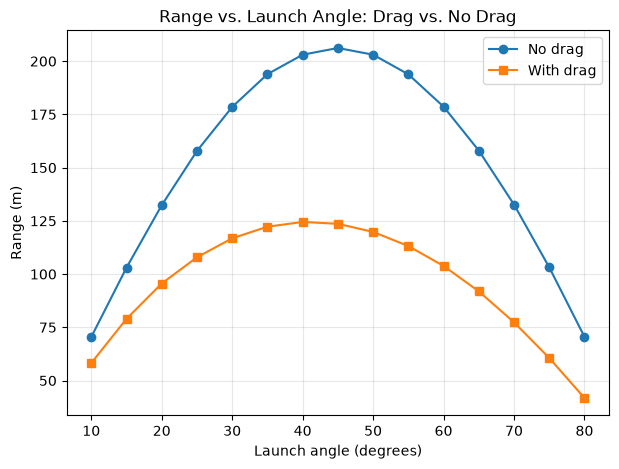

Optimal angle, no drag: 45 degrees
Optimal angle, with drag: 40 degrees


In [16]:
angles = np.arange(10, 81, 5)
ranges_drag = []

for ang in angles:
    _, x_a, y_a, _, _ = simulate_projectile_drag(v0_ball, ang, dt_c, g, b_over_m)
    ranges_drag.append(x_a[-1])

ranges_drag = np.array(ranges_drag)

ranges_nodrag_ball = []
for ang in angles:
    _, x_a, y_a, _, _ = simulate_projectile_2d(v0_ball, ang, dt_c, g)
    ranges_nodrag_ball.append(x_a[-1])
ranges_nodrag_ball = np.array(ranges_nodrag_ball)

best_angle_drag = angles[np.argmax(ranges_drag)]
best_angle_nodrag_ball = angles[np.argmax(ranges_nodrag_ball)]

plt.figure(figsize=(7, 5))
plt.plot(angles, ranges_nodrag_ball, 'o-', label='No drag')
plt.plot(angles, ranges_drag, 's-', label='With drag')
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs. Launch Angle: Drag vs. No Drag')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal angle, no drag: {best_angle_nodrag_ball} degrees")
print(f"Optimal angle, with drag: {best_angle_drag} degrees")

**Q1: Why does drag reduce the range so dramatically?**
Drag scales with the square of the speed, so it is strongest when the ball is moving fastest, which is right after launch. Cutting the speed down hard early on removes a good amount of the range. As the ball slows down, drag weakens.

**Q2: Why is the optimal launch angle with drag less than 45°?**
A higher launch angle sends more of the initial speed into the vertical direction, keeping the ball in the air longer and giving drag more time to get rid of the horizontal speed component. A flatter launch angle keeps more speed directed horizontally and gets the ball to the ground faster. The optimal angle shifts below 45 degrees because the simulation is trading off height for range against extra time in the air letting drag get rid of more of the horizontal speed.

**Q3: Is the Euler method a good choice for this problem?**
The Euler method is easy to implement but its error accumulates over time and the trajectory. More accurate methods achieve smaller error for the same step size, which matters more since there's no exact solution to check against.

## Bonus: The Home Run Problem

A baseball is hit with an initial speed of 45 m/s. The outfield fence is 120 m away and 3 m tall.

In [17]:
def height_at_distance(x_target, x_arr, y_arr):
    if x_arr[-1] < x_target:
        return None
    idx = np.searchsorted(x_arr, x_target)
    if idx == 0:
        return y_arr[0]
    x0, x1 = x_arr[idx - 1], x_arr[idx]
    y0, y1 = y_arr[idx - 1], y_arr[idx]
    frac = (x_target - x0) / (x1 - x0)
    return y0 + frac * (y1 - y0)

In [18]:
fence_x, fence_h = 120.0, 3.0
v0_hr = 45.0
dt_hr = 0.01

clears_nodrag = []
for ang in np.arange(1, 90, 1):
    _, x_a, y_a, _, _ = simulate_projectile_2d(v0_hr, ang, dt_hr, g)
    h_at_fence = height_at_distance(fence_x, x_a, y_a)
    clears = (h_at_fence is not None) and (h_at_fence >= fence_h)
    clears_nodrag.append(clears)

angles_test = np.arange(1, 90, 1)
clears_nodrag = np.array(clears_nodrag)
if clears_nodrag.any():
    good_angles = angles_test[clears_nodrag]
    print(f"No drag: angles from {good_angles.min()} degrees to {good_angles.max()} degrees clear the fence.")
else:
    print("No drag: no angle clears the fence.")

No drag: angles from 20 degrees to 72 degrees clear the fence.


In [19]:
clears_drag = []
for ang in angles_test:
    _, x_a, y_a, _, _ = simulate_projectile_drag(v0_hr, ang, dt_hr, g, b_over_m)
    h_at_fence = height_at_distance(fence_x, x_a, y_a)
    clears = (h_at_fence is not None) and (h_at_fence >= fence_h)
    clears_drag.append(clears)

clears_drag = np.array(clears_drag)
if clears_drag.any():
    good_angles_drag = angles_test[clears_drag]
    print(f"With drag: angles from {good_angles_drag.min()} degrees to {good_angles_drag.max()} degrees clear the fence.")
else:
    print("With drag: NO launch angle at v0=45 m/s clears the fence.")

With drag: angles from 37 degrees to 47 degrees clear the fence.


In [20]:
def max_fence_clearing_margin(v0_test, g, b_over_m, fence_x, angle_range):
    best_margin = -np.inf
    best_ang = None
    for ang in angle_range:
        _, x_a, y_a, _, _ = simulate_projectile_drag(v0_test, ang, dt_hr, g, b_over_m)
        h_at_fence = height_at_distance(fence_x, x_a, y_a)
        if h_at_fence is not None:
            margin = h_at_fence - fence_h
            if margin > best_margin:
                best_margin = margin
                best_ang = ang
    return best_margin, best_ang

angle_range = np.arange(20, 61, 1)
lo, hi = 30.0, 70.0
for _ in range(30):
    mid = 0.5 * (lo + hi)
    margin, ang = max_fence_clearing_margin(mid, g, b_over_m, fence_x, angle_range)
    if margin >= 0:
        hi = mid
    else:
        lo = mid

min_speed = hi
margin_check, best_ang_check = max_fence_clearing_margin(min_speed, g, b_over_m, fence_x, angle_range)
print(f"Minimum speed (with drag) for a home run: {min_speed:.2f} m/s, achieved near angle {best_ang_check} degrees")

Minimum speed (with drag) for a home run: 44.40 m/s, achieved near angle 42 degrees


Without drag, a wide band of launch angles around 45 degrees clears the 120 m fence at v_0=45 m/s. With drag included, the usable window of angles shrinks because drag take  into both the range and the height available at the fence.